## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

已知 
$$
a = [2,-1,3]^\top,\quad b = [1,4,-2]^\top
$$


矩阵

$$
A=\begin{bmatrix}1&0&2\\-1&3&1\end{bmatrix},\quad
B=\begin{bmatrix}2&1\\0&-1\\3&2\end{bmatrix}
$$

1. 内积：

    a · b =2×1+(-1)×4+3×(-2)=-8


2. 矩阵乘法：

    A 是 2×3，B 是 3×2，所以 AB 是 2×2。
    1×2+0×0+2×3=8

    1×1+0×(-1)+2×2=5

    -1×2+3×0+1×3=1

    -1×1+3×(-1)+1×2=-2

$$
AB=\begin{bmatrix}8&5\\1&-2\end{bmatrix}
$$

3. 向量 $a$ 的 Frobenius 范数：

$$
\|a\|_F = \sqrt{2^2+(-1)^2+3^2}=\sqrt{14}\approx 3.741657
$$

In [18]:
import numpy as np

# 定义向量和矩阵
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1, 0, 2],
              [-1, 3, 1]])
B = np.array([[2, 1],
              [0, -1],
              [3, 2]])

# 1. 向量点积 a · b
dot_product = np.dot(a, b)
print("1. 向量点积 a·b =", dot_product)

# 2. 矩阵乘法 A × B
# 计算矩阵乘法
AB = np.dot(A, B)
# 结果矩阵的形状
shape_AB = AB.shape
print("2. 矩阵乘法 A×B =")
print(AB)
print("   结果矩阵的形状:", shape_AB)

# 3. 向量 a 的 Frobenius 范数
# Frobenius范数 = L2范数（对于向量）
fro_norm_a = np.linalg.norm(a, ord=2)  # 计算向量的L2范数
print("3. 向量 a 的 Frobenius 范数 =", fro_norm_a)

1. 向量点积 a·b = -8
2. 矩阵乘法 A×B =
[[ 8  5]
 [ 1 -2]]
   结果矩阵的形状: (2, 2)
3. 向量 a 的 Frobenius 范数 = 3.7416573867739413


### 2.2 编程题

In [19]:
import numpy as np

# 1. 创建 3×4 随机矩阵（标准正态分布）
X = np.random.randn(3, 4)

# 2. 创建 4×2 全1矩阵
Y = np.ones((4, 2))

# 3. 计算矩阵乘法 Z = X × Y
Z = X @ Y
print("计算矩阵乘法 Z = X × Y 的结果为：")
print(Z)
print()

# 4. 输出第一行第二列交叉处的元素，以及第二行所有元素
print("输出 Z 的第一行和第二列交叉处的元素为：", Z[0, 1])
print("输出 Z 的第 2 行所有元素为：", Z[1, :])
print()

# 5. 计算 Z 的 Frobenius 范数
print("Z 的 Frobenius 范数为：", np.linalg.norm(Z))

计算矩阵乘法 Z = X × Y 的结果为：
[[-1.25016024 -1.25016024]
 [-0.90940226 -0.90940226]
 [-1.91706557 -1.91706557]]

输出 Z 的第一行和第二列交叉处的元素为： -1.250160240786653
输出 Z 的第 2 行所有元素为： [-0.90940226 -0.90940226]

Z 的 Frobenius 范数为： 3.482830311752348


## 3 概率

### 3.1 理论计算题

设患病率为 $P(D)=0.1\%=0.001$，检测真阳性率 $P(+\mid D)=99\%=0.99$，假阳性率 $P(+\mid \neg D)=2\%=0.02$。由贝叶斯公式：

$$
P(D\mid +)=\frac{P(+\mid D)P(D)}{P(+\mid D)P(D)+P(+\mid \neg D)P(\neg D)}
$$

代入得：

$$
P(D\mid +)=\frac{0.99\times 0.001}{0.99\times 0.001+0.02\times 0.999}\approx 0.04721
$$

综上所述，检测为阳性时，其真正患病的概率约为 **4.72%**。

In [20]:
# 贝叶斯公式计算
P_disease = 0.001                    # 患病率
P_positive_given_disease = 0.99      # 患病时阳性概率
P_positive_given_no = 0.02           # 未患病时阳性概率

# 全概率：P(阳性)
P_positive = 0.99 * 0.001 + 0.02 * 0.999

# 贝叶斯公式：P(患病|阳性)
P_result = (0.99 * 0.001) / P_positive

print("检测为阳性后真正患病的概率：{:.2%}".format(P_result))

检测为阳性后真正患病的概率：4.72%


### 3.2 编程题

samples 的形状 = (1000, 10000)
sample_means 的形状 = (1000,)
1000 个样本均值的平均值 = 0.499952


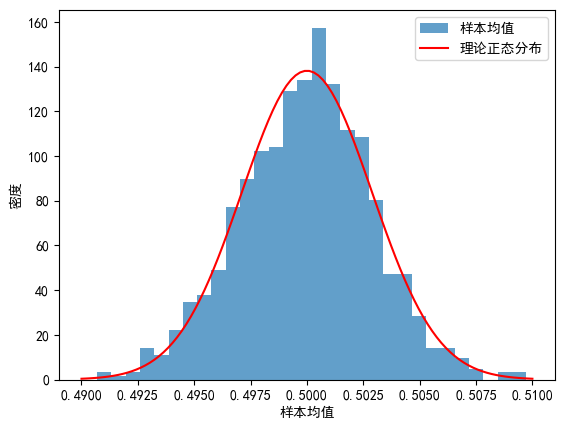

均值的实际方差 = 0.0000086140
理论方差 1/(12n) = 0.0000083333


In [21]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']  # 支持中文的字体
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 第 1 步：生成 n=10000 个 U(0,1) 随机变量，重复 m=1000 次，并计算每次的均值。
rng_32 = np.random.default_rng(2026)
n = 10_000
m = 1_000

samples = rng_32.uniform(0, 1, size=(m, n))
sample_means = samples.mean(axis=1)

print("samples 的形状 =", samples.shape)
print("sample_means 的形状 =", sample_means.shape)
print(f"1000 个样本均值的平均值 = {sample_means.mean():.6f}")

# 第 2 步：绘制直方图，叠加理论正态分布曲线
theory_mean = 0.5
theory_std = math.sqrt(1 / (12 * n))

plt.hist(sample_means, bins=30, density=True, alpha=0.7, label="样本均值")
plt.plot(np.linspace(0.49, 0.51, 100), 
         (1/(theory_std * np.sqrt(2*np.pi))) * np.exp(-0.5*((np.linspace(0.49,0.51,100)-theory_mean)/theory_std)**2),
         'r-', label="理论正态分布")
plt.xlabel("样本均值")
plt.ylabel("密度")
plt.legend()
plt.show()

# 第 3 步：计算这些均值的实际方差
actual_variance = sample_means.var()
theory_variance = 1 / (12 * n)

print(f"均值的实际方差 = {actual_variance:.10f}")
print(f"理论方差 1/(12n) = {theory_variance:.10f}")

## 4 导数、反向传播和复杂度
### 4.1 理论计算题

$$
z=(w_1x_1+w_2x_2-y)^2
$$

令

$$
e=w_1x_1+w_2x_2-y
$$

则 $z=e^2$，由链式法则：

$$
\frac{\partial z}{\partial w_1}=2e\cdot x_1=2(w_1x_1+w_2x_2-y)x_1
$$

$$
\frac{\partial z}{\partial w_2}=2e\cdot x_2=2(w_1x_1+w_2x_2-y)x_2
$$

代入 $x_1=2,x_2=1,y=3$：

$$
\frac{\partial z}{\partial w_1}=4(2w_1+w_2-3),\quad
\frac{\partial z}{\partial w_2}=2(2w_1+w_2-3)
$$

当 $w_1=0.5,w_2=1$ 时，$2w_1+w_2-3=-1$，因此：

$$
\frac{\partial z}{\partial w_1}=-4,\quad
\frac{\partial z}{\partial w_2}=-2
$$

In [22]:
x1, x2, y = 2.0, 1.0, 3.0
w1, w2 = 0.5, 1.0

error = w1*x1 + w2*x2 - y
z = error**2
dz_dw1 = 2*error*x1
dz_dw2 = 2*error*x2

print("损失值 z =", z)
print("梯度 ∂z/∂w1 =", dz_dw1)
print("梯度 ∂z/∂w2 =", dz_dw2)

损失值 z = 1.0
梯度 ∂z/∂w1 = -4.0
梯度 ∂z/∂w2 = -2.0


### 4.2 编程题

In [23]:
import torch

# 前向计算
x, w1, w2 = 2.0, 1.5, 0.5

a = x * w1
b = a + w2
L = b ** 2

print("前向结果：")
print(f"a = {a}, b = {b}, L = {L}\n")

# 手动计算梯度（链式法则）
dL_db = 2 * b
db_da = 1
da_dw1 = x
db_dw2 = 1

dL_dw1 = dL_db * db_da * da_dw1
dL_dw2 = dL_db * db_dw2

print("手动计算梯度：")
print(f"∂L/∂w1 = {dL_dw1}")
print(f"∂L/∂w2 = {dL_dw2}\n")

# PyTorch验证
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print("PyTorch自动微分：")
print(f"∂L/∂w1 = {w1_t.grad.item()}")
print(f"∂L/∂w2 = {w2_t.grad.item()}\n")

# 验证是否一致
if dL_dw1 == w1_t.grad.item() and dL_dw2 == w2_t.grad.item():
    print("验证结果：手动计算与自动微分一致")
else:
    print("验证结果：手动计算与自动微分不一致")

前向结果：
a = 3.0, b = 3.5, L = 12.25

手动计算梯度：
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

PyTorch自动微分：
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

验证结果：手动计算与自动微分一致


## 5 线性方法、基础优化和 softmax 回归

### 5.1 理论计算题

线性回归模型为

$$
\hat y_i=wx_i+b
$$

均方误差损失为

$$
L=\frac{1}{n}\sum_{i=1}^{n}\left(y_i-(wx_i+b)\right)^2
$$

令 $e_i=\hat y_i-y_i=wx_i+b-y_i$，则

$$
L=\frac{1}{n}\sum_{i=1}^{n}e_i^2
$$

对 $w$ 和 $b$ 求导：

$$
\frac{\partial L}{\partial w}=\frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)x_i
$$

$$
\frac{\partial L}{\partial b}=\frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)
$$

### 5.2 编程题

In [24]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 加载数据
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. one-hot 编码
def one_hot(y, num_classes=10):
    n = len(y)
    one_hot_y = np.zeros((n, num_classes))
    one_hot_y[np.arange(n), y] = 1
    return one_hot_y

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

# 3. softmax 和交叉熵损失
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    n = len(y_true)
    return -np.sum(y_true * np.log(y_pred + 1e-8)) / n

# 4. 训练模型
class SoftmaxRegression:
    def __init__(self, input_dim, num_classes, lr=0.1):
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros(num_classes)
        self.lr = lr
    
    def forward(self, X):
        return softmax(X @ self.W + self.b)
    
    def backward(self, X, y_pred, y_true):
        n = len(X)
        grad_logits = (y_pred - y_true) / n
        self.grad_W = X.T @ grad_logits
        self.grad_b = np.sum(grad_logits, axis=0)
    
    def update(self):
        self.W -= self.lr * self.grad_W
        self.b -= self.lr * self.grad_b
    
    def train_step(self, X, y):
        y_pred = self.forward(X)
        loss = cross_entropy(y_pred, y)
        self.backward(X, y_pred, y)
        self.update()
        return loss
    
    def predict(self, X):
        y_pred = self.forward(X)
        return np.argmax(y_pred, axis=1)

# 训练参数
input_dim = 64
num_classes = 10
batch_size = 32
lr = 0.1
epochs = 50

model = SoftmaxRegression(input_dim, num_classes, lr)
n_samples = len(X_train)

print("开始训练...")
for epoch in range(epochs):
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    total_loss = 0
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        loss = model.train_step(X_batch, y_batch)
        total_loss += loss * len(X_batch)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/n_samples:.4f}")

# 5. 测试准确率
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = np.mean(y_train_pred == y_train)
test_acc = np.mean(y_test_pred == y_test)

print(f"\n训练集准确率: {train_acc:.4f}")
print(f"测试集准确率: {test_acc:.4f}")

开始训练...
Epoch 10/50, Loss: 0.1354
Epoch 20/50, Loss: 0.0907
Epoch 30/50, Loss: 0.0715
Epoch 40/50, Loss: 0.0600
Epoch 50/50, Loss: 0.0522

训练集准确率: 0.9923
测试集准确率: 0.9750


## 6 最大似然估计和逻辑回归

### 6.1 计算题



1. 已知似然函数为：

$$
L(\mu,\sigma^2)=\prod_{i=1}^{n}\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)
$$

对应的对数似然为：

$$
\ell(\mu,\sigma^2)=-\frac{n}{2}\log(2\pi)-\frac{n}{2}\log\sigma^2-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

2. 证明：对 $\mu$ 求导：

$$
\frac{\partial \ell}{\partial \mu}=\frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu)
$$

令其等于 0：

$$
\sum_{i=1}^{n}(x_i-\mu)=0
$$
$$
\hat\mu=\frac{1}{n}\sum_{i=1}^{n}x_i
$$

3. 证明：令 $s=\sigma^2$，对 $s$ 求导：

$$
\frac{\partial \ell}{\partial s}=-\frac{n}{2s}+\frac{1}{2s^2}\sum_{i=1}^{n}(x_i-\mu)^2
$$

令其等于 0：

$$
-ns+\sum_{i=1}^{n}(x_i-\mu)^2=0
$$


$$
\hat\sigma^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat\mu)^2
$$

### 6.2 编程题

数据形状: X=(400, 2), y=(400,)
迭代次数 200/1000, 损失: 0.4240
迭代次数 400/1000, 损失: 0.3384
迭代次数 600/1000, 损失: 0.2956
迭代次数 800/1000, 损失: 0.2702
迭代次数 1000/1000, 损失: 0.2533


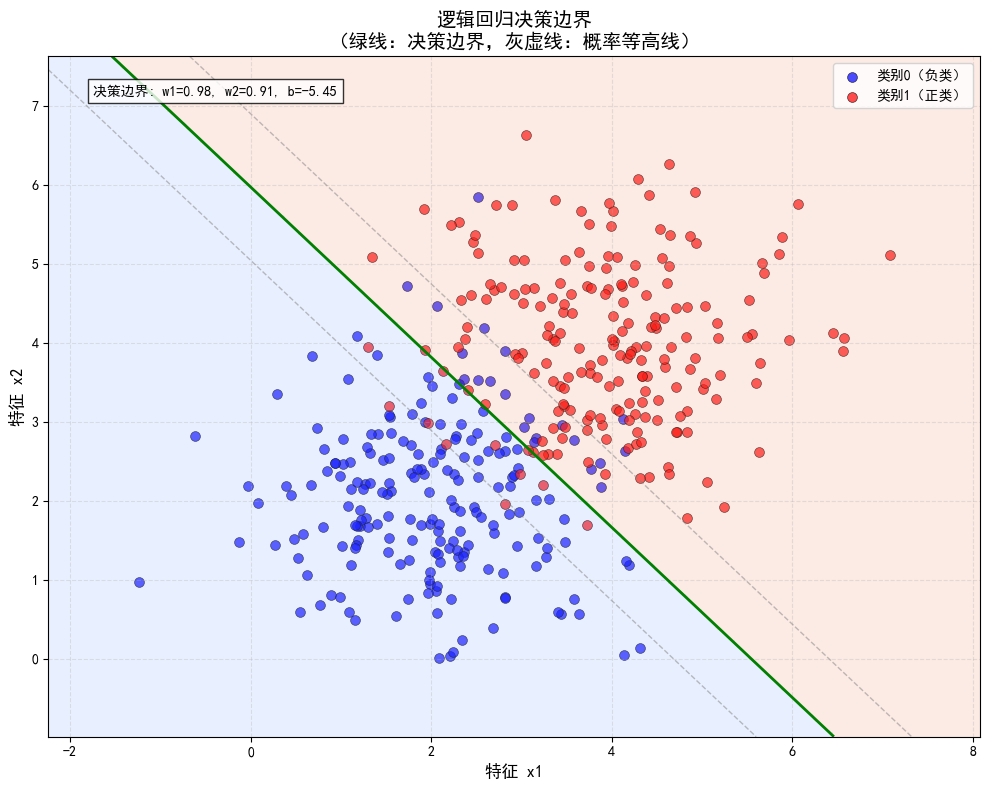

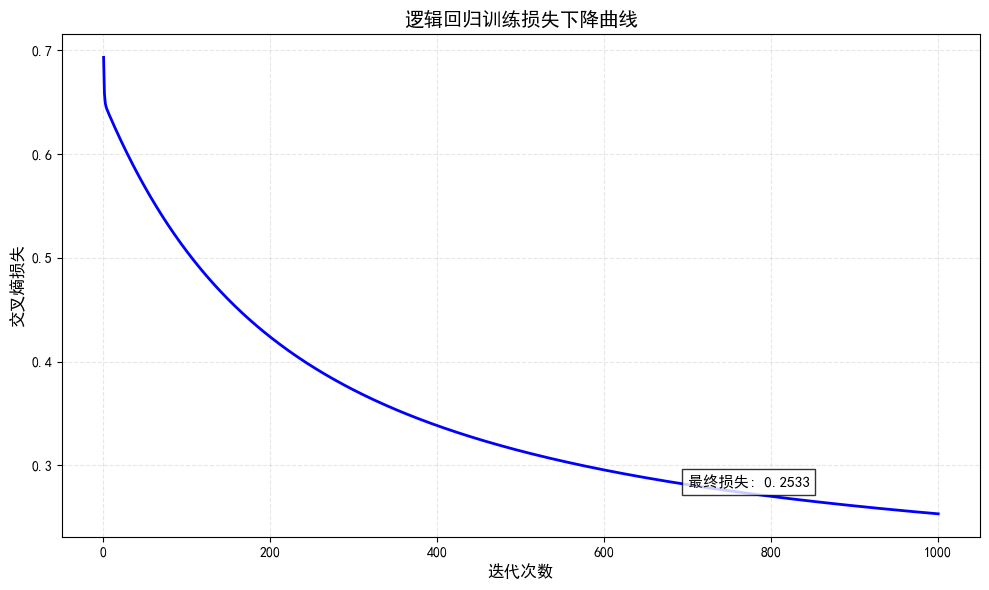


测试集准确率: 0.9000
学到的参数: w = [0.9838, 0.9127], b = -5.4546


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成两类线性可分的数据
np.random.seed(42)
n_samples = 200
# 类别0：均值为 [2, 2]
X0 = np.random.randn(n_samples, 2) + np.array([2, 2])
y0 = np.zeros(n_samples)
# 类别1：均值为 [4, 4]
X1 = np.random.randn(n_samples, 2) + np.array([4, 4])
y1 = np.ones(n_samples)

X = np.vstack([X0, X1])
y = np.hstack([y0, y1])

# 打乱数据
indices = np.random.permutation(len(X))
X, y = X[indices], y[indices]

print(f"数据形状: X={X.shape}, y={y.shape}")

# 2. 定义 sigmoid 和二元交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# 3. 梯度下降训练
class LogisticRegression:
    def __init__(self, lr=0.1, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []  # 记录损失
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        for i in range(self.n_iters):
            # 前向传播
            z = X @ self.w + self.b
            y_pred = sigmoid(z)
            
            # 计算损失并记录
            loss = binary_cross_entropy(y_pred, y)
            self.loss_history.append(loss)
            
            # 计算梯度
            dw = (1/n_samples) * (X.T @ (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            
            # 更新参数
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
            # 打印损失
            if (i+1) % 200 == 0:
                print(f"迭代次数 {i+1}/{self.n_iters}, 损失: {loss:.4f}")
    
    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# 训练模型
model = LogisticRegression(lr=0.1, n_iters=1000)
model.fit(X, y)

# 4. 绘制决策边界
def plot_decision_boundary(X, y, model):
    plt.figure(figsize=(10, 8))
    
    # 绘制数据点
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='类别0（负类）', alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='类别1（正类）', alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
    
    # 绘制决策边界
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    
    # 预测概率
    Z_prob = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z_prob = Z_prob.reshape(xx.shape)
    Z_class = (Z_prob >= 0.5).astype(int)
    
    # 绘制背景色（决策区域）
    plt.contourf(xx, yy, Z_class, alpha=0.2, cmap='coolwarm', levels=[-0.5, 0.5, 1.5])
    
    # 绘制决策边界线（概率=0.5）
    plt.contour(xx, yy, Z_prob, levels=[0.5], colors='green', linewidths=2, linestyles='-')
    
    # 绘制概率等高线
    plt.contour(xx, yy, Z_prob, levels=[0.3, 0.7], colors='gray', linewidths=1, linestyles='--', alpha=0.5)
    
    # 添加中文注释
    plt.xlabel('特征 x1', fontsize=12)
    plt.ylabel('特征 x2', fontsize=12)
    plt.title('逻辑回归决策边界\n（绿线：决策边界，灰虚线：概率等高线）', fontsize=14)
    plt.legend(loc='upper right')  # 图例放在右上角
    plt.grid(alpha=0.3, linestyle='--')
    
    # 添加参数说明
    plt.text(x_min + 0.5, y_max - 0.5, f'决策边界: w1={model.w[0]:.2f}, w2={model.w[1]:.2f}, b={model.b:.2f}', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_decision_boundary(X, y, model)

# 5. 绘制损失随迭代次数的变化曲线
def plot_loss_curve(loss_history):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(loss_history) + 1), loss_history, 'b-', linewidth=2)
    plt.xlabel('迭代次数', fontsize=12)
    plt.ylabel('交叉熵损失', fontsize=12)
    plt.title('逻辑回归训练损失下降曲线', fontsize=14)
    plt.grid(alpha=0.3, linestyle='--')
    
    # 标注最终损失
    final_loss = loss_history[-1]
    plt.text(len(loss_history) * 0.7, final_loss * 1.1, f'最终损失: {final_loss:.4f}', 
             fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

plot_loss_curve(model.loss_history)

# 生成测试集（100个新样本）
X_test0 = np.random.randn(50, 2) + np.array([2, 2])
y_test0 = np.zeros(50)
X_test1 = np.random.randn(50, 2) + np.array([4, 4])
y_test1 = np.ones(50)

X_test = np.vstack([X_test0, X_test1])
y_test = np.hstack([y_test0, y_test1])

# 预测并计算准确率
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)

print(f"\n测试集准确率: {accuracy:.4f}")
print(f"学到的参数: w = [{model.w[0]:.4f}, {model.w[1]:.4f}], b = {model.b:.4f}")